## 1. Problem Statement

# DPEL Mini Project — CA3
# Road Traffic Accident (RTA) Severity Analysis & Prediction

**Dataset:** Road Traffic Accidents — Ethiopia  
**Objective:** Analyze accident patterns and predict severity using Machine Learning

**TEAM MEMBERS-**

**ARNAV AGRAWAL-25070126034**

**NIVED NAIR-250701239**

**ARYAN-25070126036**

**PROBLEM STATEMENT:**

"Road Traffic Accidents are a major cause of death and injury worldwide. This project analyzes a real-world RTA dataset from Ethiopia containing 12,316 accident records to identify patterns that contribute to accident severity. By understanding factors like driver age, road conditions, time of day and cause of accident; we aim to derive insights that can help improve road safety and reduce fatalities."

## 2. Dataset Description


*   **Size:** 12,316 rows × 32 columns
*   **Features:** Time, Day of Week, Driver Age, Driver Gender, Driving Experience, Vehicle Type, Road Surface, Weather, Light Conditions, Cause of Accident, Number of Casualties, etc.
*   **Target Variable:** Accident_severity are of 3 classes: Slight Injury, Serious Injury, Fatal Injury




## 3. Initial Observations & Data Issues Identified

In [122]:
#importing the required librabries for now
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,accuracy_score
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler



In [123]:
#reading the csv file
df=pd.read_csv(r"C:\Games\ve\dpel project\RTA Dataset.csv")

In [124]:
#printing the top 1 rows and columns from the dataset
df.head(10)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
5,14:15:00,Friday,31-50,Male,NaN,Unknown,NaN,NaN,NaN,NaN,...,U-Turn,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Overloading,Slight Injury
6,17:30:00,Wednesday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,NaN,...,Moving Backward,Driver or rider,Female,18-30,3,Driver,Normal,Not a Pedestrian,Other,Slight Injury
7,17:20:00,Friday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Governmental,Above 10yr,...,U-Turn,na,na,na,na,NaN,Normal,Not a Pedestrian,No priority to vehicle,Slight Injury
8,17:20:00,Friday,18-30,Male,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,1-2yr,...,Going straight,Pedestrian,Male,Under 18,3,Driver,Normal,Crossing from driver's nearside,Changing lane to the right,Slight Injury
9,17:20:00,Friday,18-30,Male,Junior high school,Employee,1-2yr,Automobile,Owner,2-5yrs,...,U-Turn,Passenger,Male,18-30,3,Driver,Normal,Not a Pedestrian,Moving Backward,Serious Injury


In [125]:
#gives statistical summary of the dataset
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [126]:
#gives information about columns and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

In [127]:
#shows number of rows and columns
df.shape

(12316, 32)

In [128]:
#checking duplicated values
df.duplicated().sum()

np.int64(0)

In [129]:
# Target variable distribution
print('TARGET VARIABLE — Accident_severity:')
print(df['Accident_severity'].value_counts())
print()
print('Percentage distribution:')
print((df['Accident_severity'].value_counts() / len(df) * 100).round(2))

TARGET VARIABLE — Accident_severity:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Percentage distribution:
Accident_severity
Slight Injury     84.56
Serious Injury    14.15
Fatal injury       1.28
Name: count, dtype: float64


In [130]:
# Check missing values per column
missing = df.isnull().sum()
missing_percentage = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percentage
})

missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values('Missing %', ascending=False)
print(missing_df)

                         Missing Count  Missing %
Defect_of_vehicle                 4427      35.95
Service_year_of_vehicle           3928      31.89
Work_of_casuality                 3198      25.97
Fitness_of_casuality              2635      21.39
Type_of_vehicle                    950       7.71
Types_of_Junction                  887       7.20
Driving_experience                 829       6.73
Educational_level                  741       6.02
Vehicle_driver_relation            579       4.70
Owner_of_vehicle                   482       3.91
Lanes_or_Medians                   385       3.13
Vehicle_movement                   308       2.50
Area_accident_occured              239       1.94
Road_surface_type                  172       1.40
Type_of_collision                  155       1.26
Road_allignment                    142       1.15


In [131]:
# Check duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

# Check data types
print(f'\nData types:')
print(df.dtypes.value_counts())

# Check unique values in key columns
print('\nUnique values in key columns:')
for col in ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Accident_severity']:
    print(f'  {col}: {df[col].unique()}')

Duplicate rows: 0

Data types:
str      30
int64     2
Name: count, dtype: int64

Unique values in key columns:
  Day_of_week: <StringArray>
['Monday', 'Sunday', 'Friday', 'Wednesday', 'Saturday', 'Thursday', 'Tuesday']
Length: 7, dtype: str
  Age_band_of_driver: <StringArray>
['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown']
Length: 5, dtype: str
  Sex_of_driver: <StringArray>
['Male', 'Female', 'Unknown']
Length: 3, dtype: str
  Accident_severity: <StringArray>
['Slight Injury', 'Serious Injury', 'Fatal injury']
Length: 3, dtype: str


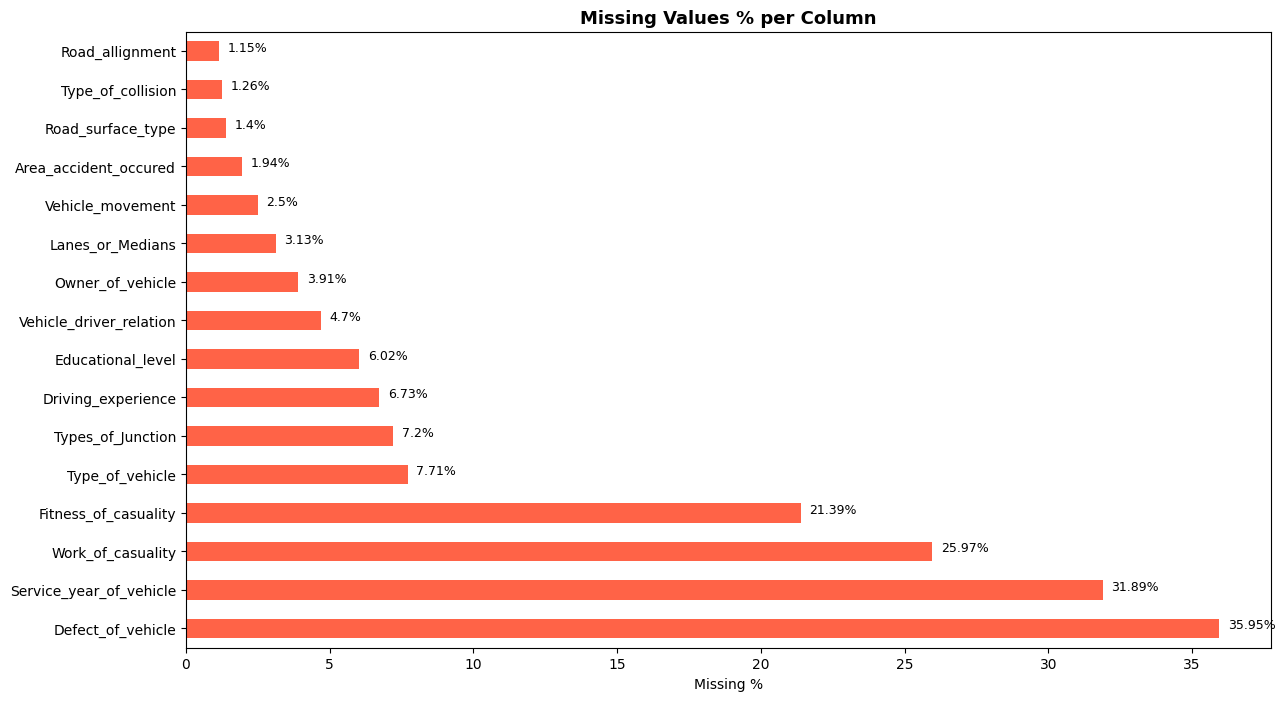

Insight: Defect_of_vehicle (35.9%) and Service_year_of_vehicle (31.9%) have the highest missing data.


In [132]:
# Visualize missing values
plt.figure(figsize=(14, 8))
ax = missing_df['Missing %'].plot(kind='barh', color='tomato')
plt.title('Missing Values % per Column', fontsize=13, fontweight='bold')
plt.xlabel('Missing %')
for i, val in enumerate(missing_df['Missing %']):
    ax.text(val + 0.3, i, f'{val}%', fontsize=9)

plt.show()
print('Insight: Defect_of_vehicle (35.9%) and Service_year_of_vehicle (31.9%) have the highest missing data.')

## 4. Handling Missing Values (with Justification)

In [133]:
df_imputed = df.copy()
mode_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = df_imputed.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)
    print(f'  [{col}] → filled with mode: "{mode_val}"')





  [Time] → filled with mode: "15:30:00"
  [Day_of_week] → filled with mode: "Friday"
  [Age_band_of_driver] → filled with mode: "18-30"
  [Sex_of_driver] → filled with mode: "Male"
  [Educational_level] → filled with mode: "Junior high school"
  [Vehicle_driver_relation] → filled with mode: "Employee"
  [Driving_experience] → filled with mode: "5-10yr"
  [Type_of_vehicle] → filled with mode: "Automobile"
  [Owner_of_vehicle] → filled with mode: "Owner"
  [Service_year_of_vehicle] → filled with mode: "Unknown"
  [Defect_of_vehicle] → filled with mode: "No defect"
  [Area_accident_occured] → filled with mode: "Other"
  [Lanes_or_Medians] → filled with mode: "Two-way (divided with broken lines road marking)"
  [Road_allignment] → filled with mode: "Tangent road with flat terrain"
  [Types_of_Junction] → filled with mode: "Y Shape"
  [Road_surface_type] → filled with mode: "Asphalt roads"
  [Road_surface_conditions] → filled with mode: "Dry"
  [Light_conditions] → filled with mode: "Daylig

C:\Users\Nived\AppData\Local\Temp\ipykernel_10664\4234260925.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_imputed.select_dtypes(include=['object']).columns.tolist()


In [134]:
# Applying median imputation to numerical columns

num_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns.tolist()
median_imputer = SimpleImputer(strategy='median')
df_imputed[num_cols] = median_imputer.fit_transform(df_imputed[num_cols])
print("Median imputation applied to numerical columns:")
for col in num_cols:
    print(f"   [{col}] → median filled")

Median imputation applied to numerical columns:
   [Number_of_vehicles_involved] → median filled
   [Number_of_casualties] → median filled


In [135]:
# Applying mean imputation to numerical columns (alternative to median)
df_mean = df.copy()
mean_imputer = SimpleImputer(strategy='mean')
df_mean[num_cols] = mean_imputer.fit_transform(df_mean[num_cols])
print("\n Mean imputation applied to numerical columns:")
for col in num_cols:
    print(f"   [{col}] → mean filled")


 Mean imputation applied to numerical columns:
   [Number_of_vehicles_involved] → mean filled
   [Number_of_casualties] → mean filled


## 5. Data Cleaning (Duplicates, Incorrect Values, Data Type Correction)

In [136]:
df_clean = df_imputed.copy()
# 1. Fix whitespace in all text columns
str_cols = df_clean.select_dtypes(include='object').columns
df_clean[str_cols] = df_clean[str_cols].apply(lambda x: x.str.strip())
print(' Whitespace removed from all text columns')

 Whitespace removed from all text columns


C:\Users\Nived\AppData\Local\Temp\ipykernel_10664\3151502404.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_clean.select_dtypes(include='object').columns


In [137]:

# 2. Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicates removed: {before - len(df_clean)}')
print(f'Rows remaining: {len(df_clean)}')

Duplicates removed: 0
Rows remaining: 12316


In [138]:
# 3. Fix inconsistent values
df_clean['Lanes_or_Medians'] = df_clean['Lanes_or_Medians'].replace({'other': 'Other'})
df_clean['Types_of_Junction'] = df_clean['Types_of_Junction'].replace({'other': 'Other'})
print('Inconsistent values fixed (other → Other)')

Inconsistent values fixed (other → Other)


In [139]:
# 4. Data type correction — Extract Hour from Time column
df_clean['Hour'] = pd.to_datetime(
    df_clean['Time'], format='%H:%M:%S', errors='coerce').dt.hour
df_clean['Hour'] = df_clean['Hour'].fillna(df_clean['Hour'].median())
df_clean['Hour'] = df_clean['Hour'].astype(int)

# Create Time_of_Day feature
def time_of_day(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'

df_clean['Time_of_Day'] = df_clean['Hour'].apply(time_of_day)
df_clean = df_clean.drop(columns=['Time'])

print(' Time column converted → Hour (int) + Time_of_Day (category)')
print(f'\nTime_of_Day distribution:')
print(df_clean['Time_of_Day'].value_counts())

 Time column converted → Hour (int) + Time_of_Day (category)

Time_of_Day distribution:
Time_of_Day
Afternoon    3897
Evening      3496
Morning      3312
Night        1611
Name: count, dtype: int64


In [140]:
# Verify cleaned data
print('AFTER CLEANING:')
print(f'Shape          : {df_clean.shape}')
print(f'Missing values : {df_clean.isnull().sum().sum()}')
print(f'Duplicates     : {df_clean.duplicated().sum()}')


AFTER CLEANING:
Shape          : (12316, 33)
Missing values : 0
Duplicates     : 0


## 6. Encoding: Label Encoding & One-Hot Encoding

In [141]:
df_encoded = df_clean.copy()
encoders = {}

# Encode all 'string' type columns (which typically hold strings/categories)
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'string' :
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
       
print("All categorical columns encoded")
df_encoded.head()

All categorical columns encoded


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour,Time_of_Day
0,1,0,1,0,0,0,0,3,3,2,...,2,5,3,0,2,5,9,2,17,1
1,1,1,1,4,0,3,11,3,2,2,...,2,5,3,0,2,5,16,2,17,1
2,1,0,1,4,0,0,5,3,5,2,...,1,1,2,0,2,5,0,1,17,1
3,3,0,1,4,0,2,11,0,5,2,...,0,0,2,0,2,5,1,2,1,3
4,3,0,1,4,0,1,0,3,2,2,...,2,5,3,0,2,5,16,2,1,3


In [142]:
# Applying One-Hot Encoding to categorical columns
df_ohe = df_clean.copy()

# Select categorical columns
cat_cols = df_ohe.select_dtypes(include= 'string').columns

df_ohe = pd.get_dummies(df_ohe, columns=cat_cols, dtype=int)

print("One-Hot Encoding applied")
print(df_ohe.head())

One-Hot Encoding applied
   Number_of_vehicles_involved  Number_of_casualties  Hour  \
0                          2.0                   2.0    17   
1                          2.0                   2.0    17   
2                          2.0                   2.0    17   
3                          2.0                   2.0     1   
4                          2.0                   2.0     1   

   Day_of_week_Friday  Day_of_week_Monday  Day_of_week_Saturday  \
0                   0                   1                     0   
1                   0                   1                     0   
2                   0                   1                     0   
3                   0                   0                     0   
4                   0                   0                     0   

   Day_of_week_Sunday  Day_of_week_Thursday  Day_of_week_Tuesday  \
0                   0                     0                    0   
1                   0                     0                    

## 7. Scaling / Normalization / Standardization

In [143]:
# Standardizing numerical columns using StandardScaler (mean=0, std=1)
df_std = df_clean.copy()

scaler = StandardScaler()

num_cols = df_std.select_dtypes(include=['int64', 'float64']).columns

df_std[num_cols] = scaler.fit_transform(df_std[num_cols])

print("Standardization applied")
print(df_std.select_dtypes(include=['int64', 'float64']).head())

Standardization applied
   Number_of_vehicles_involved  Number_of_casualties      Hour
0                    -0.059061              0.448649  0.608178
1                    -0.059061              0.448649  0.608178
2                    -0.059061              0.448649  0.608178
3                    -0.059061              0.448649 -2.467141
4                    -0.059061              0.448649 -2.467141


In [144]:
# Normalizing numerical columns using MinMaxScaler (range 0 to 1)


df_norm = df_clean.copy()

scaler = MinMaxScaler()

# Select numerical columns only
num_cols = df_norm.select_dtypes(include=['int64', 'float64']).columns

# Apply normalization
df_norm[num_cols] = scaler.fit_transform(df_norm[num_cols])

print("Normalization applied")
print(df_norm.head())

Normalization applied
  Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0      Monday              18-30          Male   Above high school   
1      Monday              31-50          Male  Junior high school   
2      Monday              18-30          Male  Junior high school   
3      Sunday              18-30          Male  Junior high school   
4      Sunday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr           Automobile   

  Owner_of_vehicle Service_year_of_vehicle Defect_of_vehicle  ...  \
0            Owner              Above 10yr         No defect  ...   
1   

## 8. Outlier Detection (with Justification)

In [145]:
# Use original (pre-scaled) values for outlier detection
num_data_orig = df_clean[['Number_of_vehicles_involved', 'Number_of_casualties']]

# IQR Method
print('OUTLIER DETECTION — IQR Method:')
print('=' * 45)
for col in num_data_orig.columns:
    Q1 = num_data_orig[col].quantile(0.25)
    Q3 = num_data_orig[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = num_data_orig[(num_data_orig[col] < lower) | (num_data_orig[col] > upper)]
    print(f'  {col}:')
    print(f'    IQR = {IQR:.2f}, Lower bound = {lower:.2f}, Upper bound = {upper:.2f}')
    print(f'    Outliers found: {len(outliers)} ({len(outliers)/len(num_data_orig)*100:.2f}%)')

OUTLIER DETECTION — IQR Method:
  Number_of_vehicles_involved:
    IQR = 0.00, Lower bound = 2.00, Upper bound = 2.00
    Outliers found: 3976 (32.28%)
  Number_of_casualties:
    IQR = 1.00, Lower bound = -0.50, Upper bound = 3.50
    Outliers found: 720 (5.85%)


In [146]:
# Z-Score Method
print('OUTLIER DETECTION — Z-Score Method (|Z| > 3):')

for col in num_data_orig.columns:
    z_scores = np.abs(stats.zscore(num_data_orig[col]))
    outliers_z = (z_scores > 3).sum()
    print(f'  {col}: {outliers_z} outliers detected')

OUTLIER DETECTION — Z-Score Method (|Z| > 3):
  Number_of_vehicles_involved: 49 outliers detected
  Number_of_casualties: 326 outliers detected


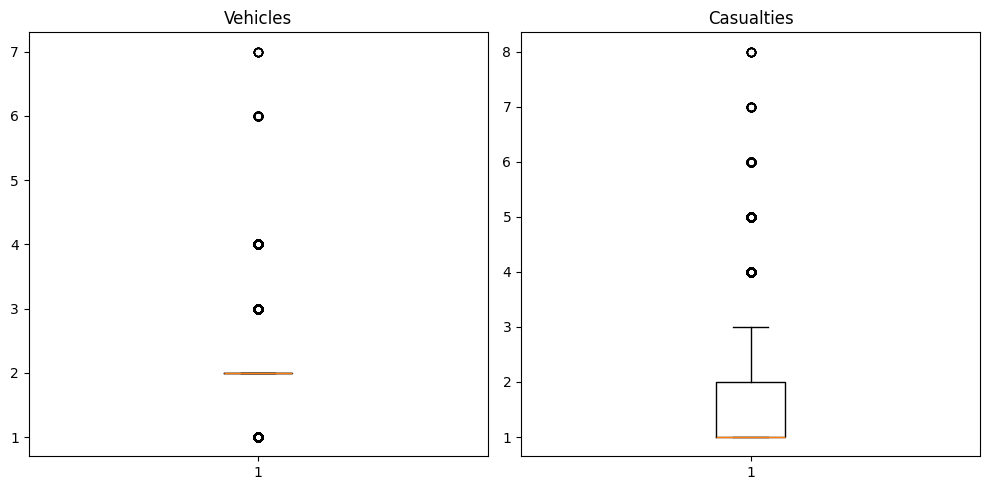

Insight: High-value outliers exist (rare extreme accidents).


In [147]:
# Boxplot to visually detect outliers in numerical columns


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df_clean['Number_of_vehicles_involved'].dropna())
plt.title('Vehicles')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['Number_of_casualties'].dropna())
plt.title('Casualties')

plt.tight_layout()
plt.show()

print("Insight: High-value outliers exist (rare extreme accidents).")

## 9. Exploratory Data Analysis (EDA) & Visualizations

### 9.1 Grouping, Sorting & Ranking

In [148]:
# Grouping — avg casualties by severity
print('Average casualties by Accident Severity:')
print(df_clean.groupby('Accident_severity')['Number_of_casualties'].mean().round(2))

Average casualties by Accident Severity:
Accident_severity
Fatal injury      2.34
Serious Injury    1.54
Slight Injury     1.54
Name: Number_of_casualties, dtype: float64


In [149]:
# Sorting — most dangerous causes
print('Top 10 Most Common Causes of Accidents:')
print(df_clean['Cause_of_accident'].value_counts().head(10))

Top 10 Most Common Causes of Accidents:
Cause_of_accident
No distancing                           2263
Changing lane to the right              1808
Changing lane to the left               1473
Driving carelessly                      1402
No priority to vehicle                  1207
Moving Backward                         1137
No priority to pedestrian                721
Other                                    456
Overtaking                               430
Driving under the influence of drugs     340
Name: count, dtype: int64


In [150]:
# Ranking — which day has most accidents
day_counts = df_clean['Day_of_week'].value_counts().reset_index()
day_counts.columns = ['Day', 'Count']
day_counts['Rank'] = day_counts['Count'].rank(ascending=False).astype(int)
print('Accident count by Day (ranked):')
print(day_counts.sort_values('Rank'))



Accident count by Day (ranked):
         Day  Count  Rank
0     Friday   2041     1
1   Thursday   1851     2
2  Wednesday   1840     3
3    Tuesday   1770     4
4     Monday   1681     5
5   Saturday   1666     6
6     Sunday   1467     7


In [151]:
# Groupby multiple columns
print('Accidents by Gender and Severity:')
print(df_clean.groupby(['Sex_of_driver', 'Accident_severity']).size().unstack(fill_value=0))

Accidents by Gender and Severity:
Accident_severity  Fatal injury  Serious Injury  Slight Injury
Sex_of_driver                                                 
Female                        5             104            592
Male                        152            1621           9664
Unknown                       1              18            159


### 9.2 Correlation Analysis

Text(0.5, 1.0, 'Pearson Correlation Matrix')

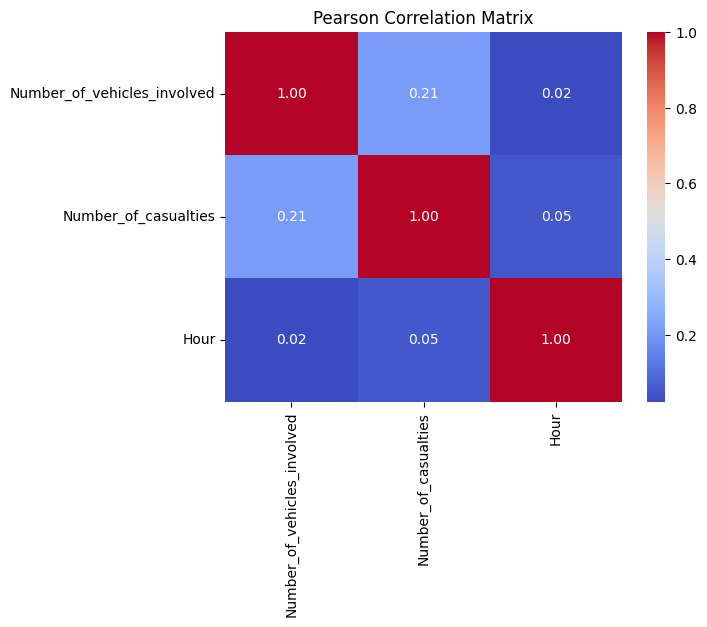

In [152]:
# Computing Pearson, Kendall and Spearman correlation matrices
num_df = df_clean.select_dtypes(include=['int64', 'float64'])

pearson_corr = num_df.corr(method='pearson')
kendall_corr = num_df.corr(method='kendall')
spearman_corr = num_df.corr(method='spearman')

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')


Text(0.5, 1.0, 'Kendall Correlation Matrix')

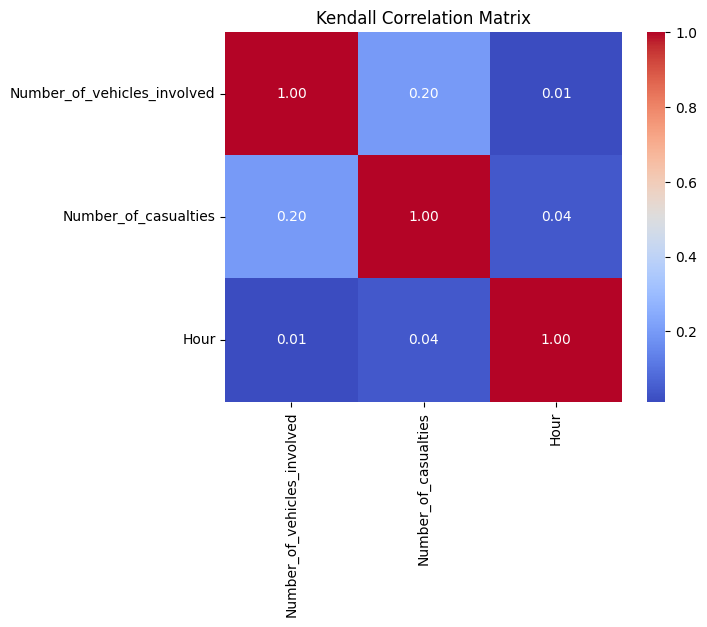

In [153]:
# Plotting Kendall Correlation Heatmap
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Kendall Correlation Matrix')

Text(0.5, 1.0, 'Spearman Correlation Matrix')

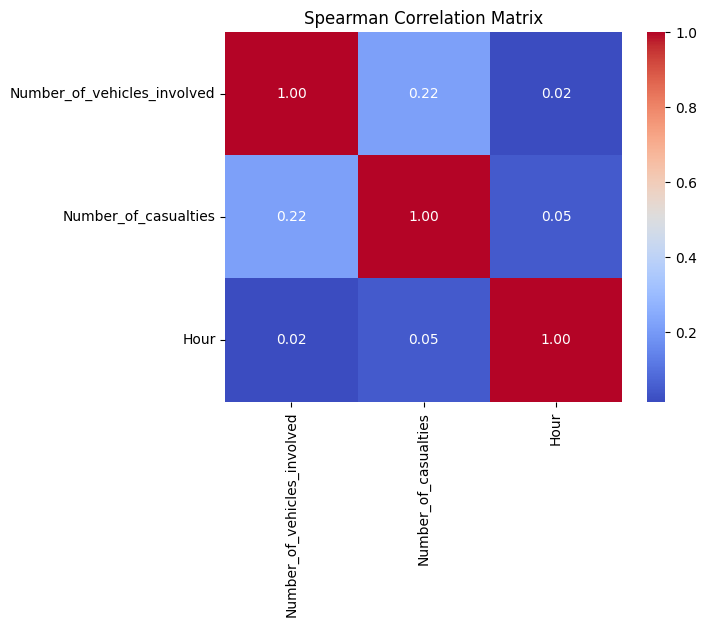

In [154]:
# Plotting Spearman Correlation Heatmap
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Correlation Matrix')

### 9.3 Univariate Analysis

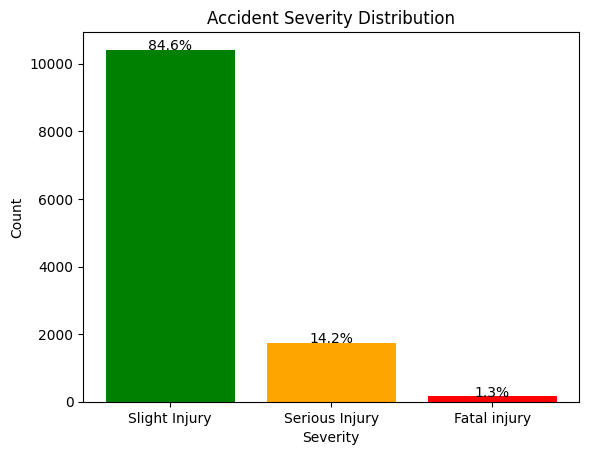

Insight: Most accidents (84.6%) result in Slight Injury. Fatal injuries are very rare at 1.3%.


In [155]:
# Univariate Analysis - Accident Severity Distribution
severity_counts = df_clean['Accident_severity'].value_counts()

plt.bar(severity_counts.index, severity_counts.values, color=['green', 'orange', 'red'])
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
for i, v in enumerate(severity_counts.values):
    plt.text(i, v , f'{v/len(df_clean)*100:.1f}%',ha="center")
plt.show()

print("Insight: Most accidents (84.6%) result in Slight Injury. Fatal injuries are very rare at 1.3%.")

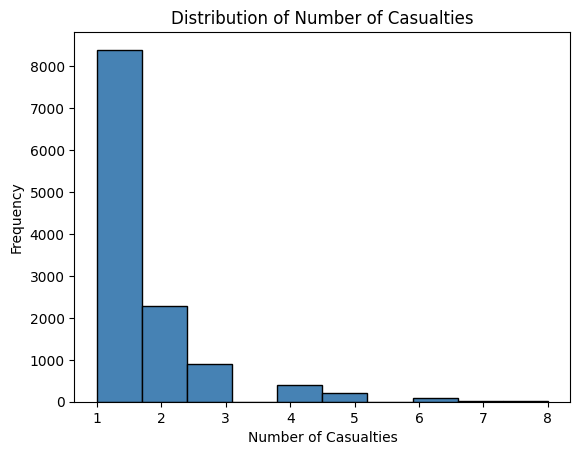

Insight: Most accidents involve 1-2 casualties. Distribution is right-skewed.


In [156]:
# Histogram - Distribution of Number of Casualties
plt.hist(df_clean['Number_of_casualties'], bins=10, color='steelblue', edgecolor='black')
plt.title('Distribution of Number of Casualties')
plt.xlabel('Number of Casualties')
plt.ylabel('Frequency')
plt.show()

print("Insight: Most accidents involve 1-2 casualties. Distribution is right-skewed.")

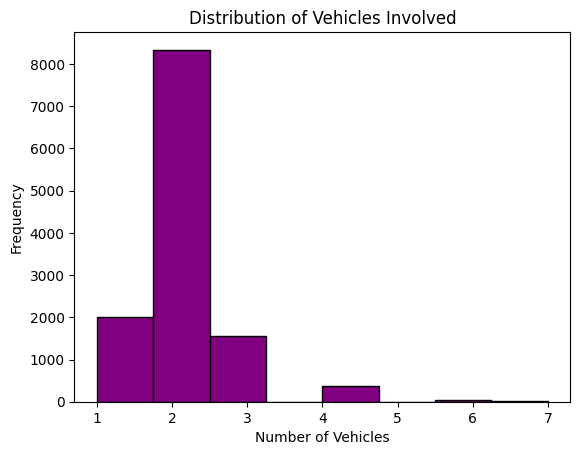

In [157]:
# Histogram - Number of Vehicles Involved
plt.hist(df_clean['Number_of_vehicles_involved'], bins=8, color='purple', edgecolor='black')
plt.title('Distribution of Vehicles Involved')
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')
plt.show()

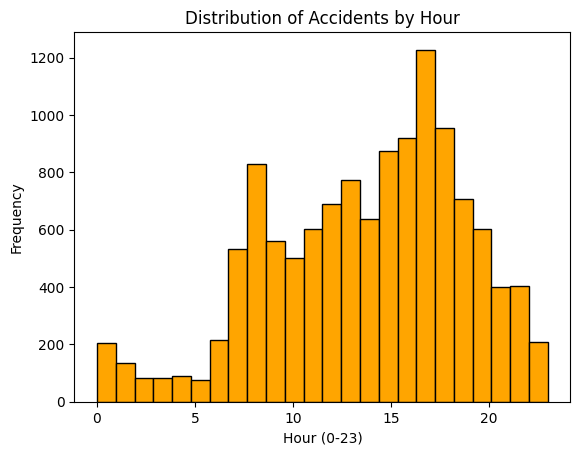

Insight: Accidents peak in evening hours (17-19). This is likely due to rush hour traffic.


In [158]:
# Histogram - Hour of Accident

plt.hist(df_clean['Hour'], bins=24, color='orange', edgecolor='black')
plt.title('Distribution of Accidents by Hour')
plt.xlabel('Hour (0-23)')
plt.ylabel('Frequency')
plt.show()

print("Insight: Accidents peak in evening hours (17-19). This is likely due to rush hour traffic.")

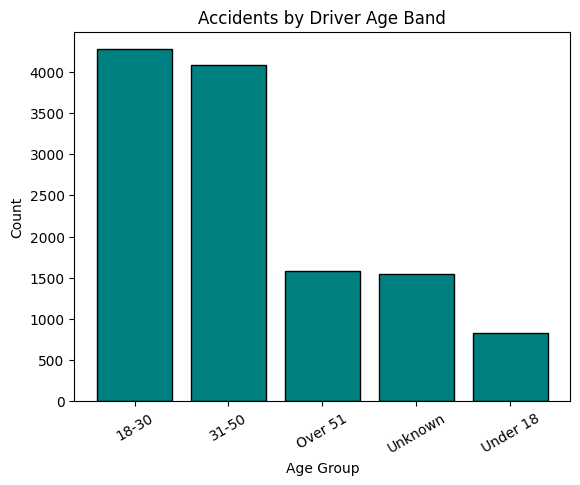

Insight: Drivers aged 18-30 are involved in the most accidents.


In [159]:
# Bar chart - Driver Age Band
age_counts = df_clean['Age_band_of_driver'].value_counts()

plt.bar(age_counts.index, age_counts.values, color='teal', edgecolor='black')
plt.title('Accidents by Driver Age Band')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

print("Insight: Drivers aged 18-30 are involved in the most accidents.")

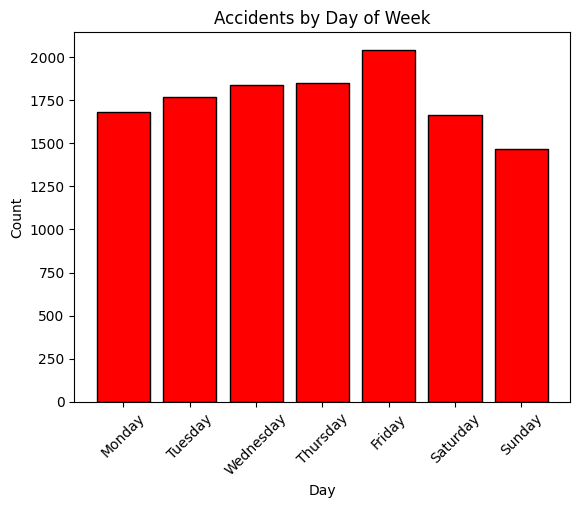

Insight: Friday has the highest number of accidents.


In [160]:
# Bar chart - Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df_clean['Day_of_week'].value_counts().reindex(day_order)

plt.bar(day_counts.index, day_counts.values, color='red', edgecolor='black')
plt.title('Accidents by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("Insight: Friday has the highest number of accidents.")

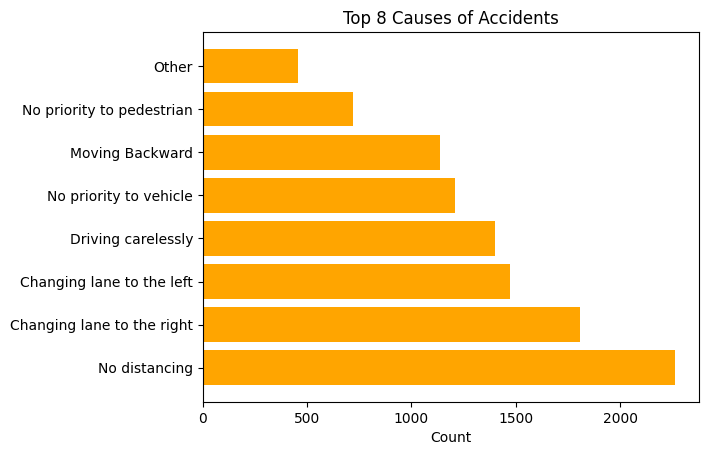

Insight: No distancing and overtaking are the top causes of accidents.


In [161]:
# Top 8 Causes of Accidents
top_causes = df_clean['Cause_of_accident'].value_counts().head(8)

plt.barh(top_causes.index, top_causes.values, color='orange')
plt.title('Top 8 Causes of Accidents')
plt.xlabel('Count')
plt.show()

print("Insight: No distancing and overtaking are the top causes of accidents.")

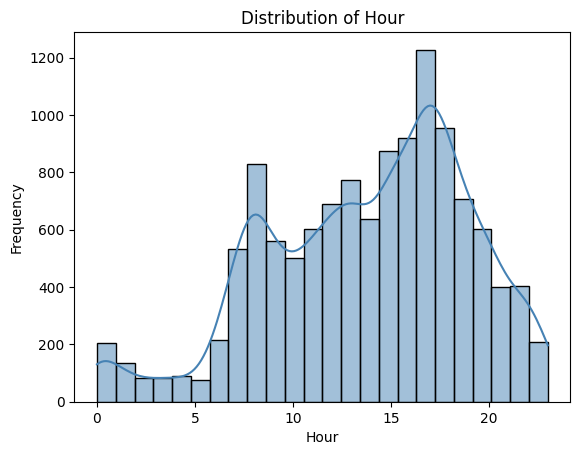

In [162]:
# Histogram - Distribution by Hour
sns.histplot(df_clean['Hour'], bins=24, color='steelblue', kde=True)
plt.title('Distribution of Hour')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.show()

### 9.4 Bivariate Analysis

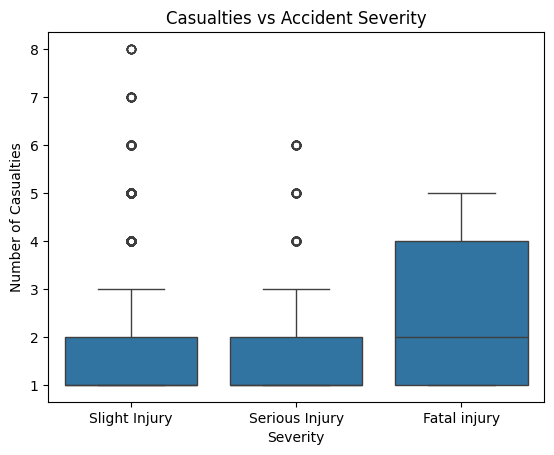

Insight: Fatal accidents have higher casualty counts compared to Slight Injury.


In [163]:
# BIVARIATE ANALYSIS
# Boxplot - Number of Casualties vs Accident Severity
sns.boxplot(data=df_clean, x='Accident_severity', y='Number_of_casualties')
plt.title('Casualties vs Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Number of Casualties')
plt.show()

print("Insight: Fatal accidents have higher casualty counts compared to Slight Injury.")

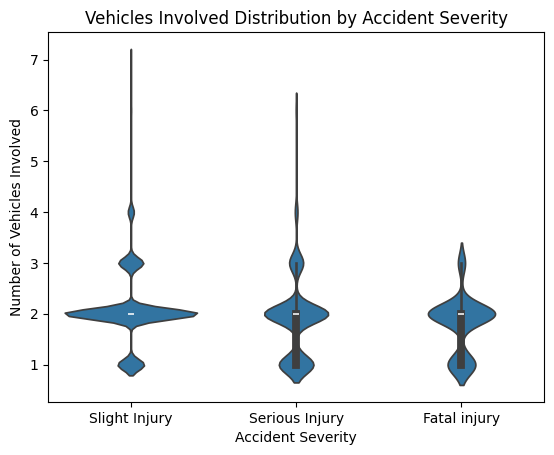

In [164]:
# Violin Plot - Vehicles Involved vs Accident Severity
sns.violinplot(data=df_clean, x='Accident_severity', y='Number_of_vehicles_involved')


plt.title('Vehicles Involved Distribution by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Vehicles Involved')

plt.show()

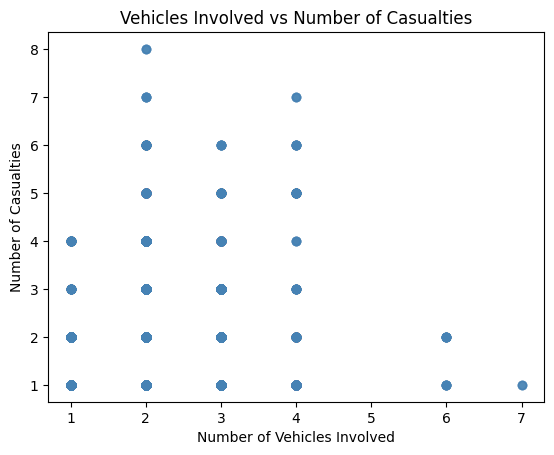

Insight: More vehicles involved generally leads to more casualties.


In [165]:
# Scatter Plot - Vehicles Involved vs Casualties
plt.scatter(df_clean['Number_of_vehicles_involved'],
            df_clean['Number_of_casualties'],
            alpha=0.3, color='steelblue')
plt.title('Vehicles Involved vs Number of Casualties')
plt.xlabel('Number of Vehicles Involved')
plt.ylabel('Number of Casualties')
plt.show()

print("Insight: More vehicles involved generally leads to more casualties.")

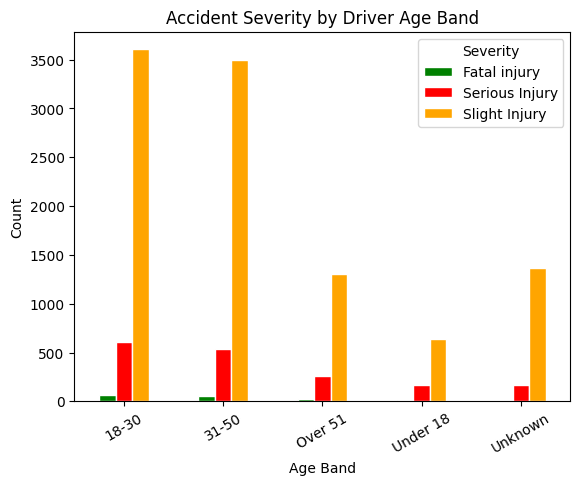

Insight: 18-30 age group dominates all severity levels.


In [166]:
# Grouped Bar - Severity by Driver Age Band
age_sev = df_clean.groupby(['Age_band_of_driver', 'Accident_severity']).size().unstack(fill_value=0)
age_sev.plot(kind='bar', color=['green', 'red', 'orange'], edgecolor='white')
plt.title('Accident Severity by Driver Age Band')
plt.xlabel('Age Band')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Severity')
plt.show()

print("Insight: 18-30 age group dominates all severity levels.")

### 9.5 Multivariate Analysis

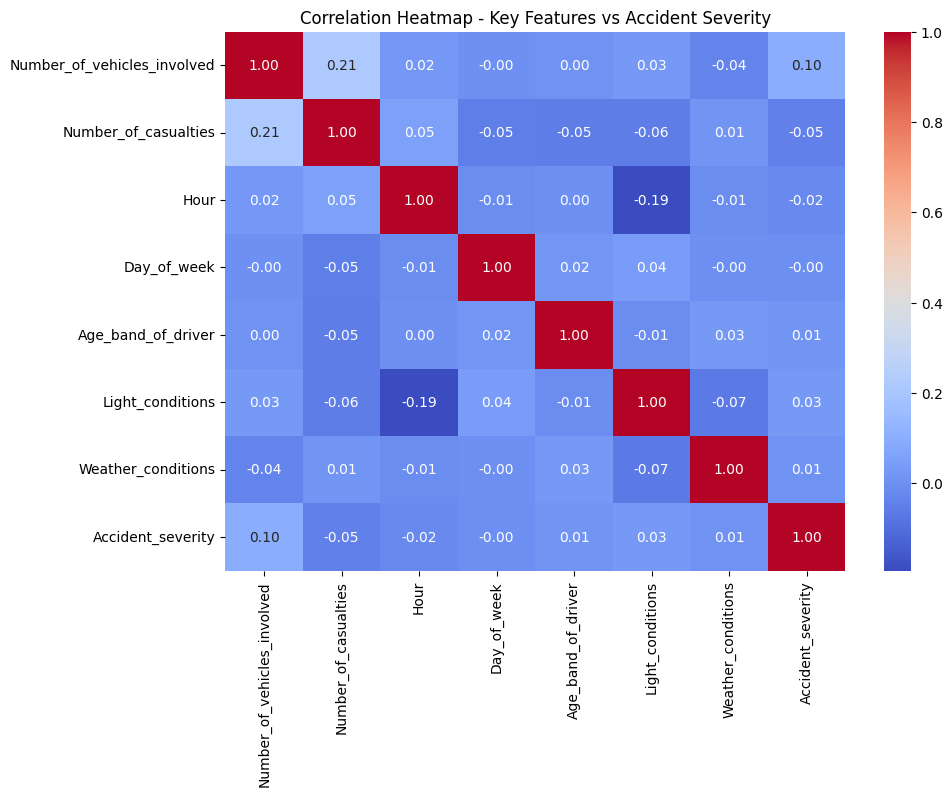

Insight: Number of casualties has the strongest correlation with accident severity.


In [167]:
#multivariate
# Heatmap - Correlation between key features
key_cols = ['Number_of_vehicles_involved', 'Number_of_casualties',
            'Hour', 'Day_of_week', 'Age_band_of_driver',
            'Light_conditions', 'Weather_conditions', 'Accident_severity']

plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded[key_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Key Features vs Accident Severity')
plt.show()

print("Insight: Number of casualties has the strongest correlation with accident severity.")

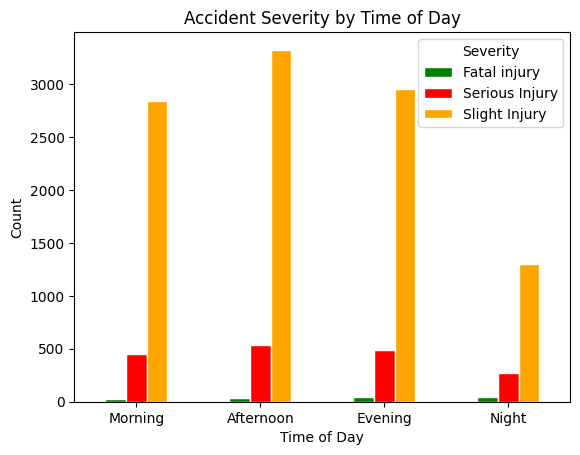

Insight: Evening has the highest accident count — rush hour effect.


In [168]:
# Grouped Bar - Severity by Time of Day
tod_sev = df_clean.groupby(['Time_of_Day', 'Accident_severity']).size().unstack(fill_value=0)
tod_sev = tod_sev.reindex(['Morning', 'Afternoon', 'Evening', 'Night'])

tod_sev.plot(kind='bar', color=['green', 'red', 'orange'], edgecolor='white')
plt.title('Accident Severity by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Severity')
plt.show()

print("Insight: Evening has the highest accident count — rush hour effect.")

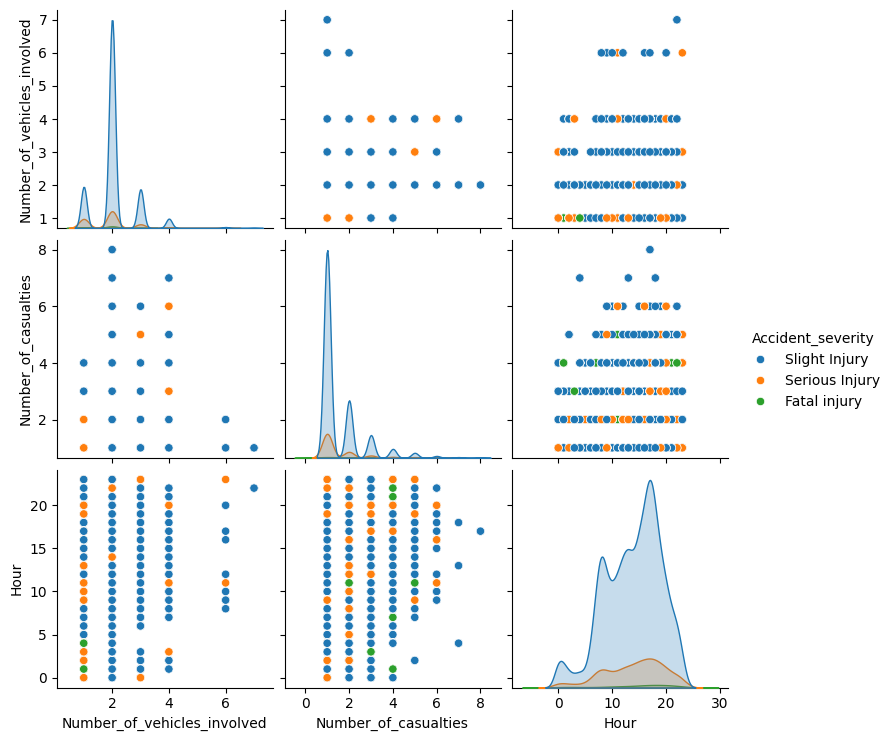

In [178]:
# Select relevant columns
cols = ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'Accident_severity']

sns.pairplot(df_clean[cols], hue='Accident_severity')
plt.show()

## 10. Machine Learning Pipeline

In [169]:
x = df_encoded.drop(columns=['Accident_severity']) # All columns except target
y = df_encoded['Accident_severity'] # Only target column


In [170]:
# Splitting dataset into train (70%) and test (30%) sets

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [171]:
# Displaying training features
x_train

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Hour,Time_of_Day
4759,6,1,1,2,0,0,0,3,5,2,...,2,0,1,2,0,2,5,0,7,2
5676,6,1,1,1,0,4,14,3,3,2,...,0,1,0,2,3,2,5,16,6,2
353,3,4,0,4,0,0,7,3,5,2,...,0,1,0,2,0,2,5,3,6,2
6223,2,1,1,4,0,2,9,3,3,2,...,0,1,0,2,0,2,5,1,4,3
456,5,3,1,2,0,1,0,1,2,2,...,0,1,1,2,0,2,5,12,11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,6,4,1,4,0,0,8,3,2,2,...,0,0,0,2,0,2,5,3,17,1
5191,6,1,1,1,0,1,0,3,1,2,...,0,1,1,2,0,2,5,0,17,1
5390,6,1,1,0,2,2,0,0,5,2,...,0,1,0,2,0,2,5,9,12,0
860,4,2,1,2,2,2,0,3,1,2,...,0,1,1,2,0,2,5,10,8,2


In [172]:
# Displaying testing features
x_test

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Hour,Time_of_Day
4281,0,2,1,4,0,3,0,3,1,2,...,3,2,5,3,0,2,5,0,14,0
4010,3,3,1,4,0,4,0,3,5,2,...,3,2,5,3,0,2,5,3,16,0
1022,6,0,1,4,0,2,0,3,5,2,...,0,1,0,2,0,2,5,10,16,0
8775,5,1,1,4,0,4,9,3,5,2,...,0,1,0,2,3,2,5,9,15,0
10000,0,1,1,4,0,3,11,3,5,2,...,1,0,1,2,0,2,5,10,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9855,6,0,1,1,0,4,0,3,2,2,...,0,1,1,2,0,2,5,10,16,0
7302,4,0,1,4,0,2,8,3,5,1,...,3,2,5,3,3,2,5,12,6,2
9023,4,1,1,4,0,1,6,3,5,2,...,3,2,5,3,0,2,5,11,8,2
7936,3,0,1,4,2,3,5,3,2,2,...,0,1,1,2,0,2,5,16,17,1


In [173]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
mselr = mean_squared_error(y_test, y_pred)
maelr= mean_absolute_error(y_test,y_pred)
acclr=accuracy_score(y_test,y_pred)
print(f"Mean Squared Error: {mselr:.4f}")
print(f"Mean Squared Error: {maelr:.4f}")
print(f"Accuracy Score:{acclr:.4f}")

Mean Squared Error: 0.2057
Mean Squared Error: 0.1775
Accuracy Score:0.8365


c:\Games\ve\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [174]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
mserf = mean_squared_error(y_test, y_pred)
maerf= mean_absolute_error(y_test,y_pred)
accrf=accuracy_score(y_test,y_pred)
print(f"Mean Squared Error: {mserf:.4f}")
print(f"Mean Squared Error: {maerf:.4f}")
print(f"Accuracy Score:{accrf:.4f}")



Mean Squared Error: 0.2035
Mean Squared Error: 0.1759
Accuracy Score:0.8379


In [175]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
msedt = mean_squared_error(y_test, y_pred)
maedt= mean_absolute_error(y_test,y_pred)
accdt= accuracy_score(y_test, y_pred)
print(f"Mean Squared Error: {msedt:.4f}")
print(f"Mean Squared Error: {maedt:.4f}")
print(f"Accuracy: {accdt:.4f}")

Mean Squared Error: 0.3118
Mean Squared Error: 0.2706
Accuracy: 0.7499


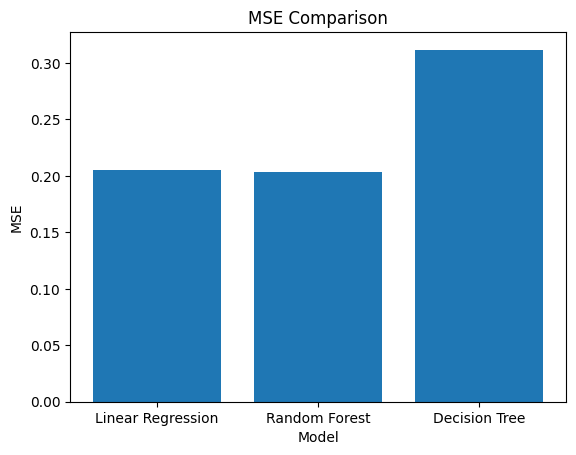

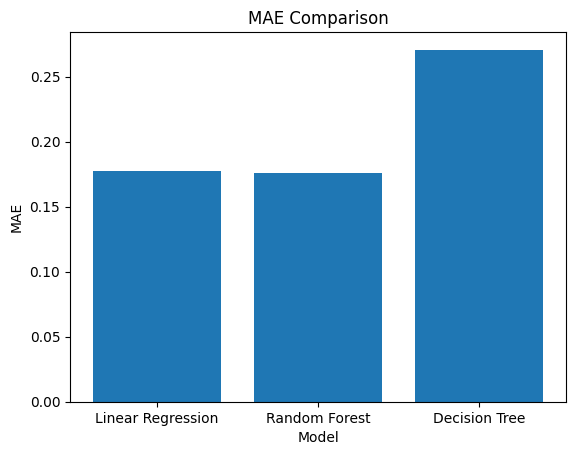

In [176]:
# Comparing MSE and MAE of all models using bar charts
data = {
    "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
    "MSE": [mselr, mserf, msedt],
    "MAE": [maelr, maerf, maedt]
}

df_model= pd.DataFrame(data)
plt.figure()
plt.bar(df_model["Model"], df_model["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.show()

# Bar plot for MAE
plt.figure()
plt.bar(df_model["Model"], df_model["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()


### Additional — KNN Classifier

In [177]:
# Features & target
X_knn = df.drop('Accident_severity', axis=1)
y_knn = df['Accident_severity']

# Convert categorical to numeric (quick way)
X_knn = pd.get_dummies(X_knn)

# Split data
X_knn_train, X_knn_test, y_knn_train, y_knn_test = train_test_split(X_knn, y_knn, test_size=0.2)

# Train model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_knn_train, y_knn_train)

# Predict
predictions = model.predict(X_knn_test)

# Accuracy
print("Accuracy:", (predictions == y_knn_test).mean())

Accuracy: 0.8267045454545454
